Last edited: 2/9/2026, 10:22 AM CST
# Nonstationary CMIP ERA5 Fit Analysis

In this notebook, I compare the results of fitting a nonstationary distribution to maximum temperature anomalies over land in ERA5.

In [2]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from config import DATA_ROOT

# import custom stuff
from src.plotting_presets import get_presets

# import custom stuff
from ambpy.plotutils import make_figure_filename

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

save_figs = True

In [3]:
TMIN = 1979
GRID = '1deg'
ds_max = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_t2m_annual_max_{GRID}_landonly_gev_nonstat_TMIN{TMIN}.nc', engine='netcdf4')
ds_min = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_t2m_annual_min_{GRID}_landonly_gev_nonstat_TMIN{TMIN}.nc', engine='netcdf4')

## GEV parameter maps

In [4]:
def plot_nonstat_gev_parameters(ds, anom_type, vars, suptitle=None, save_fig=True,
                                filename_args=['gev-k', 'png', 'figs']):
    """
    Plot four xarray DataArrays (shape, loc, scale, k) on a 2x2 world map grid.

    Parameters
    ----------
    shape, loc, scale, k : xr.DataArray
        2D DataArrays with coordinates (lat, lon)
    titles : list or tuple of str, optional
        Custom titles for the subplots. Defaults to ['Shape', 'Location', 'Scale', 'k'].
    save_fig : bool, optional
        If True, saves the figure to `fname`.
    fname : str, optional
        Output filename if save_fig=True.
    """

    # Set up the 2x2 grid
    fig, axes = plt.subplot_mosaic(
        [
            ['A', 'B'],
            ['C', 'D'],
            ['E', 'F']
        ],
        figsize=(14, 14),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # adjust layout to reduce whitespace 

    das = [ds[f'loc_{anom_type}'],
           ds[f'loc_t_{anom_type}'] / len(ds.year.values) * 10.,  # convert to per decade 
           ds[f'scale_{anom_type}'],
           ds[f'scale_t_{anom_type}'] / len(ds.year.values) * 10.,  # convert to per decade 
           ds[f'shape_{anom_type}'],
           ds[f'shape_t_{anom_type}'] / len(ds.year.values) * 10.  # convert to per decade
    ]
    
    always_positive = [0, 2]

    for idx, (it, da, var) in enumerate(zip(axes.items(), das, vars)):
        lab, ax = it
        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor="white")

        # Determine colormap and vmin/vmax based on parameter type
        if idx in always_positive:
            # Use sequential colormap (one half of PuOr) for always-positive parameters
            cmap = "Oranges"  # Or "YlOrBr" for consistency with orange side of PuOr
            vmin = np.nanpercentile(da.values, 5)
            vmax = np.nanpercentile(da.values, 95)
        else:
            # Use diverging colormap centered on zero for parameters that can be +/-
            cmap = "PuOr_r"
            vmax = np.nanpercentile(np.abs(da.values), 95)
            vmin = -vmax

        # Plot the parameter
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            add_colorbar=False,
            vmin=vmin,
            vmax=vmax
        )

        # Add an aligned colorbar on the right of each plot
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
        cbar.set_label(var)

    # add labels
    for label, ax in axes.items():
        ax.text(0.02, 1.05, f'{label}', 
                transform=ax.transAxes,
                fontsize=14, fontweight='bold',
                va='bottom', ha='right')
        ax.set_title('')

    if suptitle is not None:
        fig.suptitle(suptitle)

    fig.subplots_adjust(left=0.05, right=0.85, top=0.55, bottom=0.02)

    if save_figs:
        fname = make_figure_filename(*filename_args)
        plt.savefig(fname, dpi=300, bbox_inches="tight")
        print(f'Figure saved to: {fname}')
    plt.show()

## Annual maxima

In [70]:
anom_type = 'anom_annmean'

Figure saved to: figs/analysis/2026-03-25-era5-t2m-max-anom_annmean-gev-nonstat-parameters-1deg-1979.png


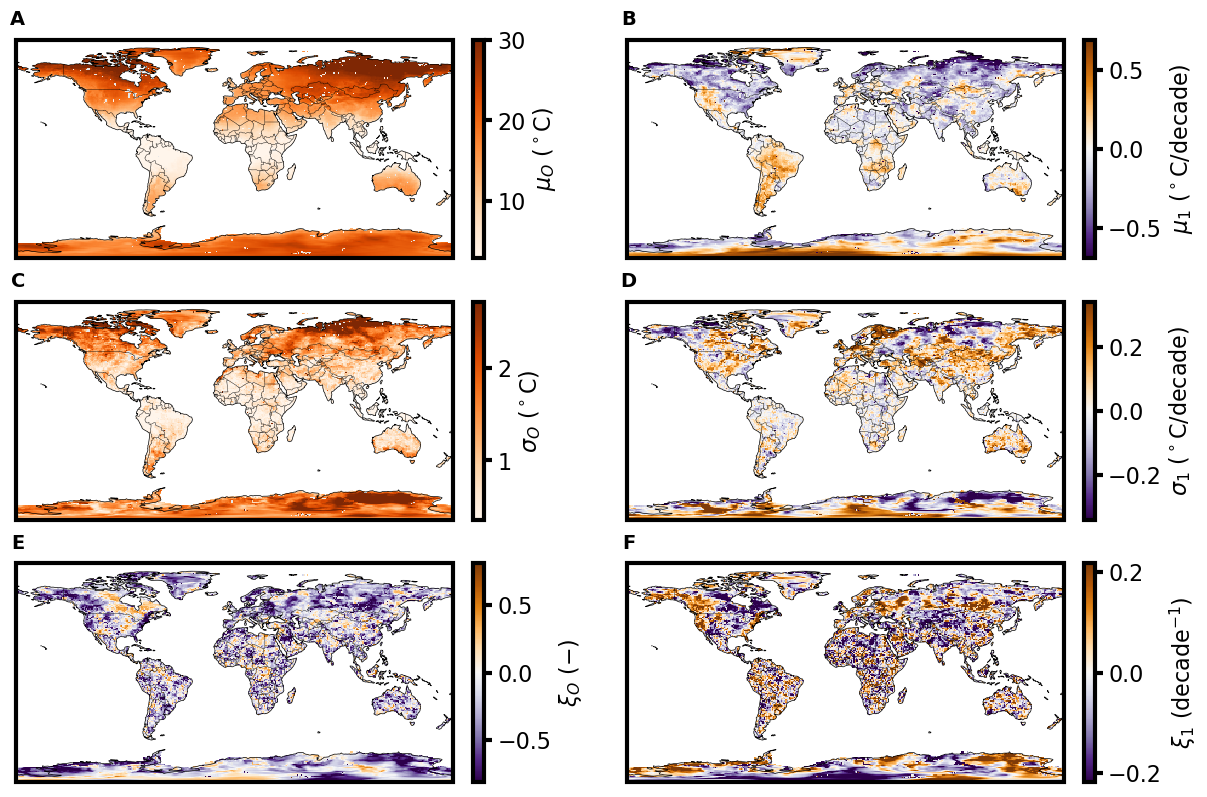

In [71]:
plot_nonstat_gev_parameters(ds_max, anom_type=anom_type,
                            vars=[r'$\mu_O$ ($^\circ$C)', r'$\mu_1$ ($^\circ$C/decade)', 
                                  r'$\sigma_O$ ($^\circ$C)', r'$\sigma_1$ ($^\circ$C/decade)', 
                                  r'$\xi_O$ ($-$)', r'$\xi_1$ (decade$^{-1}$)'],
                                    filename_args=[f'era5-t2m-max-{anom_type}-gev-nonstat-parameters-{GRID}-{TMIN}', 'png', 'figs/analysis'])

In [72]:
def area_weighted_average(ds: xr.Dataset, var: str, plo: float = 0, phi: float = 100) -> float:
    """
    Compute the area-weighted average of the 't2m' variable in an xarray Dataset.
 
    Area weighting accounts for the fact that grid cells at higher latitudes
    cover a smaller surface area than those near the equator. Each cell is
    weighted by the cosine of its latitude, which is proportional to its area
    on a spherical Earth.
 
    NaN values in 't2m' are excluded from both the weighted sum and the
    sum of weights, so they do not bias the result.
 
    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing:
          - 'lat'  : latitude coordinate (degrees), named 'lat' or 'latitude'
          - 'lon'  : longitude coordinate (degrees), named 'lon' or 'longitude'

    var : string
        variable key

    plo : float (default = 0)
        lower percentile to mask out

    phi : float (default = 100)
        higher percentile to mask out
 
    Returns
    -------
    float
        The area-weighted mean of 't2m', ignoring NaNs.
 
    Raises
    ------
    ValueError
        If no latitude coordinate can be identified, or if all values are NaN.
    """
 
    # ------------------------------------------------------------------ #
    # 1. Identify the latitude coordinate (flexible naming)               #
    # ------------------------------------------------------------------ #
    lat_names = ["lat", "latitude", "LAT", "LATITUDE"]
    lat_coord = next((n for n in lat_names if n in ds.coords), None)
    if lat_coord is None:
        raise ValueError(
            f"Could not find a latitude coordinate. Expected one of {lat_names}. "
            f"Available coords: {list(ds.coords)}"
        )
 
    # ------------------------------------------------------------------ #
    # 2. Build cosine-of-latitude weights                                 #
    # ------------------------------------------------------------------ #
    lats_rad = np.deg2rad(ds[lat_coord])          # convert degrees → radians
    weights = np.cos(lats_rad)                    # shape: (n_lat,)
 
    # Broadcast weights to the full shape of t2m so NaN masking is easy
    # xarray handles the broadcast automatically via `.weighted()`
    weights_da = xr.ones_like(ds[var]) * weights / sum(weights) # shape: (n_lat, n_lon)
 
    # ------------------------------------------------------------------ #
    # 3a. Mask weights where t2m is NaN                                    #
    # ------------------------------------------------------------------ #
    valid_mask = ~np.isnan(ds[var])
    masked_weights = weights_da.where(valid_mask)   # NaN where t2m is NaN

    # ------------------------------------------------------------------ #
    # 3b. compute percentiles to mask values 
    # ------------------------------------------------------------------ #
    var_plo = np.nanpercentile(ds[var], plo)
    var_phi = np.nanpercentile(ds[var], phi)

    # ------------------------------------------------------------------ #
    # 4. Compute weighted mean manually (works with any xarray version)   #
    # ------------------------------------------------------------------ #
    weighted_sum = (
        ds[var].where(
            (ds[var] <= var_phi) & (ds[var] >= var_plo)
            ) * masked_weights
        ).sum(skipna=True)
    weight_total = masked_weights.sum(skipna=True)
 
    if float(weight_total) == 0:
        raise ValueError("All 'var' values are NaN — cannot compute a weighted mean.")
 
    result = float(weighted_sum / weight_total)
    return result

In [77]:
print(f" ---- FOR {anom_type} AND MAXIMUM TEMPERATURES ----")
print(f"The area weighted average stationary part of the location parameter is {area_weighted_average(ds_max, f'loc_{anom_type}', 1, 99)} deg C")
print(f"The area weighted average trend in the location parameter is {area_weighted_average(ds_max, f'loc_t_{anom_type}', 1, 99) / len(ds_max.year.values) * 10.} deg C / decade")

print(f"The area weighted average stationary part of the scale parameter is {area_weighted_average(ds_max, f'scale_{anom_type}', 1, 99)} deg C")
print(f"The area weighted average trend in the scale parameter is {area_weighted_average(ds_max, f'scale_t_{anom_type}', 1, 99) / len(ds_max.year.values) * 10.} deg C / decade")

print(f"The area weighted average stationary part of the shape parameter is {area_weighted_average(ds_max, f'shape_{anom_type}', 1, 99)}")
print(f"The area weighted average trend in the shape parameter is {area_weighted_average(ds_max, f'shape_t_{anom_type}', 1, 99) / len(ds_max.year.values) * 10.} per decade")


 ---- FOR anom_annmean AND MAXIMUM TEMPERATURES ----
The area weighted average stationary part of the location parameter is 13.889734318100402 deg C
The area weighted average trend in the location parameter is -0.03566053935833612 deg C / decade
The area weighted average stationary part of the scale parameter is 1.0472819241891291 deg C
The area weighted average trend in the scale parameter is 0.020108053479588155 deg C / decade
The area weighted average stationary part of the shape parameter is -0.2233428030439409
The area weighted average trend in the shape parameter is -0.015088703578769189 per decade


## Annual minima

Figure saved to: figs/2026-02-09-era5-t2m-min-raw-gev-nonstat-parameters-1deg-1979.png


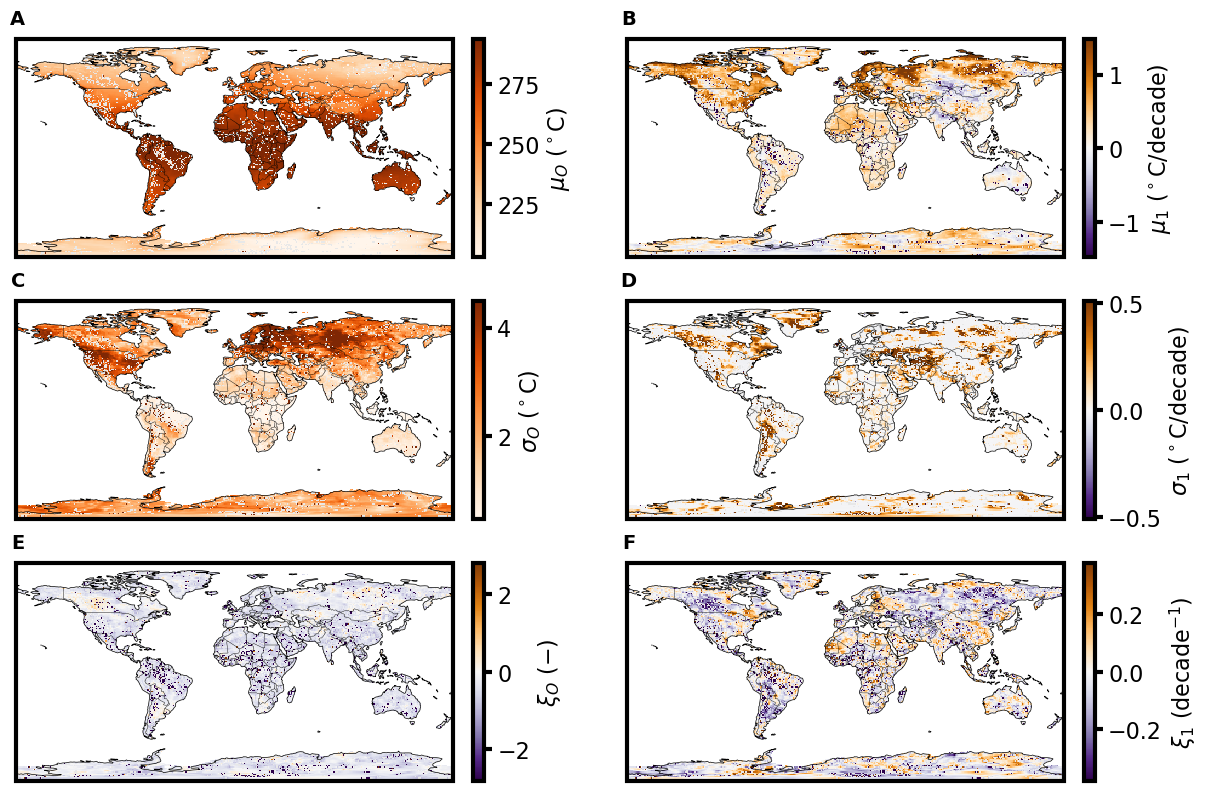

In [35]:
plot_nonstat_gev_parameters(ds_min, anom_type=anom_type,
                            vars=[r'$\mu_O$ ($^\circ$C)', r'$\mu_1$ ($^\circ$C/decade)', 
                                  r'$\sigma_O$ ($^\circ$C)', r'$\sigma_1$ ($^\circ$C/decade)', 
                                  r'$\xi_O$ ($-$)', r'$\xi_1$ (decade$^{-1}$)'],
                                    filename_args=[f'era5-t2m-min-{anom_type}-gev-nonstat-parameters-{GRID}-{TMIN}', 'png', 'figs'])